In [38]:
import pandas as pd
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
import os
import re
import seaborn as sns

In [39]:
model_traces = {}

later_drops = pd.read_csv("later_drops.csv")
batches = sorted(later_drops['Batch_ID'].unique())

for current_batch in batches:
    file_path = f"v1_traces/trace_batch_{current_batch}.nc"
    
    if os.path.exists(file_path):
        # Load the trace from disk back into memory
        model_traces[current_batch] = az.from_netcdf(file_path)
        print(f"Loaded Batch {current_batch} successfully.")
    else:
        print(f"File not found: {file_path}")

Loaded Batch 3 successfully.
Loaded Batch 4 successfully.
Loaded Batch 5 successfully.
Loaded Batch 7 successfully.
Loaded Batch 8 successfully.
Loaded Batch 9 successfully.
Loaded Batch 10 successfully.
Loaded Batch 11 successfully.
Loaded Batch 12 successfully.
Loaded Batch 13 successfully.
Loaded Batch 14 successfully.
Loaded Batch 15 successfully.
Loaded Batch 16 successfully.
Loaded Batch 17 successfully.
Loaded Batch 18 successfully.
Loaded Batch 19 successfully.
Loaded Batch 20 successfully.
Loaded Batch 21 successfully.
Loaded Batch 22 successfully.
Loaded Batch 23 successfully.
Loaded Batch 24 successfully.
Loaded Batch 25 successfully.
Loaded Batch 26 successfully.
Loaded Batch 27 successfully.


In [40]:
# Build the same race index used during training
first_drop = pd.read_csv("first_drop.csv")

all_races = np.unique(np.concatenate((first_drop['Race'], later_drops['Race'])))
n_races = len(all_races)

race_cat_type = pd.CategoricalDtype(categories=all_races, ordered=True)
first_drop['race_idx'] = first_drop['Race'].astype(race_cat_type).cat.codes

baseline_array = first_drop.sort_values('race_idx')['Dem_Prop_Before_11_08'].values

print("Races (index order):", all_races)
print("Baselines:          ", baseline_array.round(4))

Races (index order): ['AD-58' 'CD-13' 'CD-21' 'CD-22' 'CD-40' 'CD-41' 'CD-45' 'CD-47' 'CD-49'
 'CD-9' 'SD-19' 'SD-37' 'SD-5']
Baselines:           [0.4871 0.4862 0.5057 0.4495 0.436  0.4849 0.4809 0.4989 0.5112 0.5069
 0.4668 0.4828 0.5016]


In [41]:
final_tally = later_drops[later_drops["Batch_ID"] == 27].set_index("Race").sort_values("Race")
official_dem_prop = final_tally["D"].divide(final_tally["Total Votes Cast"])
official_dem_prop

Race
AD-58    0.498090
CD-13    0.500443
CD-21    0.525738
CD-22    0.465789
CD-40    0.447397
CD-41    0.483090
CD-45    0.501034
CD-47    0.514390
CD-49    0.521735
CD-9     0.517921
SD-19    0.452421
SD-37    0.493377
SD-5     0.528612
dtype: float64

In [42]:
def get_posterior_samples(trace, baseline_array, n_races):
    """
    Returns shape (total_draws, n_races).
    Each column is posterior samples of (baseline + s_r + s_g) for that race,
    i.e. the full joint posterior on the expected Dem proportion.
    """
    s_r = trace.posterior['s_r'].values  # (chains, draws, n_races)
    s_g = trace.posterior['s_g'].values  # (chains, draws)
    n_chains, n_draws, _ = s_r.shape
    s_r_flat = s_r.reshape(n_chains * n_draws, n_races)
    s_g_flat = s_g.reshape(n_chains * n_draws)
    return baseline_array + s_r_flat + s_g_flat[:, np.newaxis]

## Posterior Evolution

For each race, the 94% HDI and posterior mean across all batches. Orange line = official final result; black dashed = first-drop baseline.

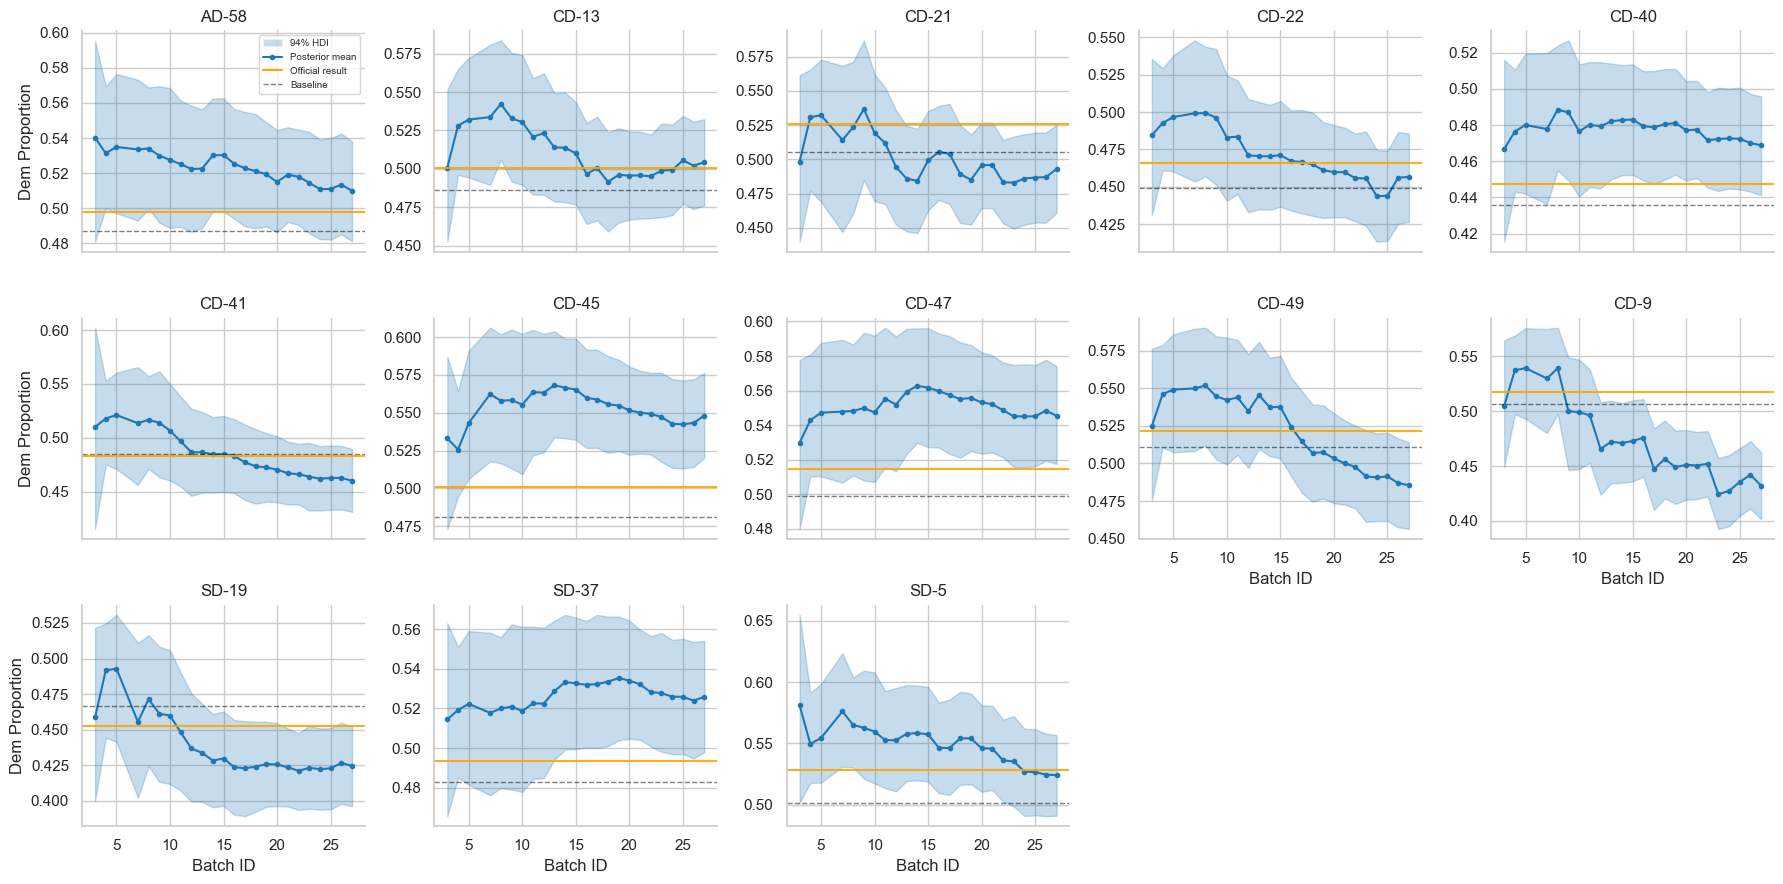

In [43]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# Build per-batch posterior summary for every race
post_records = []

for batch_id, trace in model_traces.items():
    samples  = get_posterior_samples(trace, baseline_array, n_races)
    mean_val = samples.mean(axis=0)
    lower_94 = np.quantile(samples, 0.03, axis=0)
    upper_94 = np.quantile(samples, 0.97, axis=0)

    for i, race in enumerate(all_races):
        post_records.append({
            'Batch_ID': batch_id,
            'Race':     race,
            'mean':     mean_val[i],
            'lower_94': lower_94[i],
            'upper_94': upper_94[i],
            'baseline': baseline_array[i],
        })

post_df = pd.DataFrame(post_records).sort_values(['Race', 'Batch_ID'])

# --- plotting function applied per facet ---
def plot_posterior_evolution(data, **kwargs):
    ax  = plt.gca()
    race = data['Race'].iloc[0]

    ax.fill_between(data['Batch_ID'], data['lower_94'], data['upper_94'],
                    alpha=0.25, color='#1f77b4')
    ax.plot(data['Batch_ID'], data['mean'],
            color='#1f77b4', marker='o', markersize=3, lw=1.5)
    ax.axhline(data['baseline'].iloc[0],
               color='black', linestyle='--', lw=1, alpha=0.5)
    if race in official_dem_prop.index:
        ax.axhline(official_dem_prop.loc[race],
                   color='orange', lw=1.5, alpha=0.9)

sns.set_theme(style='whitegrid')
g = sns.FacetGrid(post_df, col='Race', col_wrap=5, sharey=False, height=3, aspect=1.2)
g.map_dataframe(plot_posterior_evolution)
g.set_axis_labels('Batch ID', 'Dem Proportion')
g.set_titles(col_template='{col_name}')

legend_elements = [
    Patch(facecolor='#1f77b4', alpha=0.25, label='94% HDI'),
    Line2D([0], [0], color='#1f77b4', marker='o', markersize=3, label='Posterior mean'),
    Line2D([0], [0], color='orange', lw=1.5, label='Official result'),
    Line2D([0], [0], color='black', linestyle='--', lw=1, alpha=0.5, label='Baseline'),
]
g.axes[0].legend(handles=legend_elements, fontsize=7, loc='best')

plt.tight_layout()
plt.show()

## Diagnostic 1: Calibration

At each batch `t`, for each race, check whether the official result (batch-27 posterior mean) falls inside the model's HDI. A well-calibrated model's 94% interval should contain the truth ~94% of the time across races.

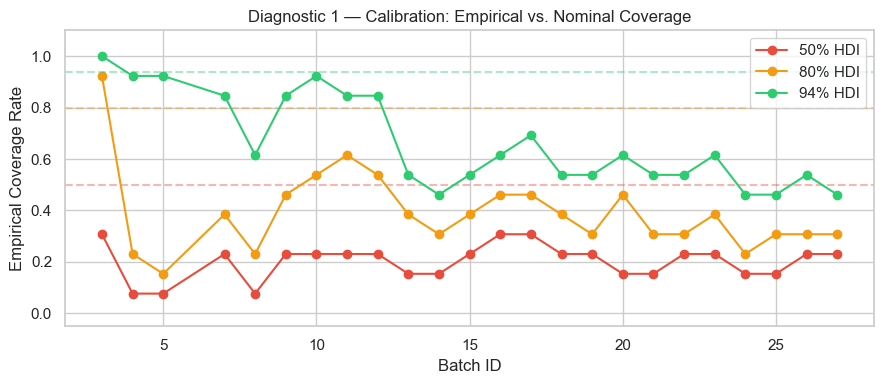

In [44]:
credible_levels = [0.50, 0.80, 0.94]
coverage_records = []

for batch_id, trace in model_traces.items():
    samples = get_posterior_samples(trace, baseline_array, n_races)  # (draws, n_races)

    for level in credible_levels:
        alpha = 1 - level
        lower = np.quantile(samples, alpha / 2, axis=0)       # (n_races,)
        upper = np.quantile(samples, 1 - alpha / 2, axis=0)   # (n_races,)

        for i, race in enumerate(all_races):
            y = official_dem_prop.loc[race]
            coverage_records.append({
                'Batch_ID': batch_id,
                'Race':     race,
                'Level':    level,
                'Covered':  bool(lower[i] <= y <= upper[i]),
                'Lower':    lower[i],
                'Upper':    upper[i],
            })

coverage_df = pd.DataFrame(coverage_records)

rate_df = (coverage_df
    .groupby(['Batch_ID', 'Level'])['Covered']
    .mean()
    .reset_index()
    .rename(columns={'Covered': 'Coverage_Rate'}))

# --- plot ---
sns.set_theme(style='whitegrid')
fig, ax = plt.subplots(figsize=(9, 4))
colors = {0.50: '#e74c3c', 0.80: '#f39c12', 0.94: '#2ecc71'}

for level in credible_levels:
    sub = rate_df[rate_df['Level'] == level]
    ax.plot(sub['Batch_ID'], sub['Coverage_Rate'],
            marker='o', label=f'{int(level*100)}% HDI', color=colors[level])
    ax.axhline(level, linestyle='--', color=colors[level], alpha=0.4)

ax.set_xlabel('Batch ID')
ax.set_ylabel('Empirical Coverage Rate')
ax.set_title('Diagnostic 1 — Calibration: Empirical vs. Nominal Coverage')
ax.set_ylim(-0.05, 1.1)
ax.legend()
plt.tight_layout()
plt.show()

## Diagnostic 2: Prediction Error Over Time

MAE and RMSE between the posterior mean and the official result, averaged across all 13 races, at each batch. Both should decrease monotonically as more data arrives.

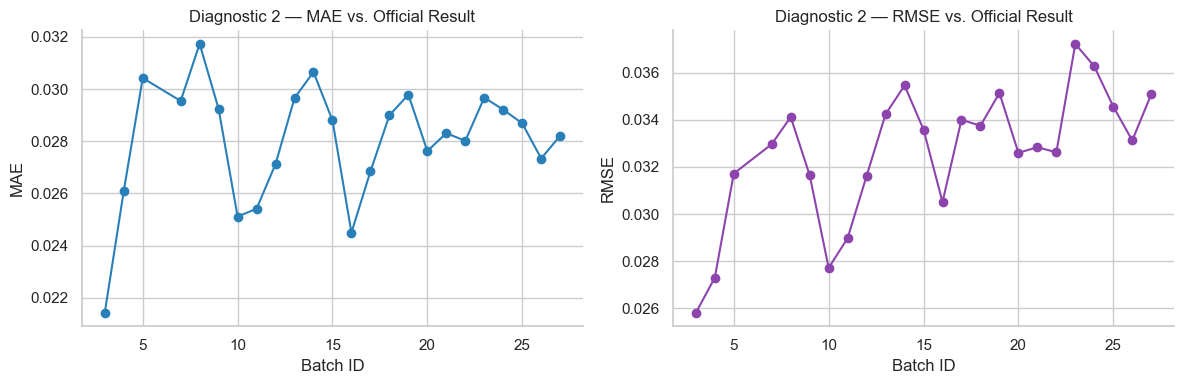

 Batch_ID    MAE   RMSE
        3 0.0214 0.0258
        4 0.0261 0.0273
        5 0.0304 0.0317
        7 0.0295 0.0330
        8 0.0317 0.0341
        9 0.0292 0.0316
       10 0.0251 0.0277
       11 0.0254 0.0290
       12 0.0271 0.0316
       13 0.0297 0.0342
       14 0.0307 0.0355
       15 0.0288 0.0336
       16 0.0245 0.0305
       17 0.0268 0.0340
       18 0.0290 0.0337
       19 0.0298 0.0351
       20 0.0276 0.0326
       21 0.0283 0.0328
       22 0.0280 0.0326
       23 0.0297 0.0372
       24 0.0292 0.0363
       25 0.0287 0.0346
       26 0.0273 0.0331
       27 0.0282 0.0351


In [45]:
accuracy_records = []

for batch_id, trace in model_traces.items():
    s_r_mean = trace.posterior['s_r'].values.mean(axis=(0, 1))   # (n_races,)
    s_g_mean = float(trace.posterior['s_g'].values.mean())        # scalar
    expected  = baseline_array + s_r_mean + s_g_mean             # (n_races,)

    for i, race in enumerate(all_races):
        err = expected[i] - official_dem_prop.loc[race]
        accuracy_records.append({
            'Batch_ID': batch_id,
            'Race':     race,
            'Error':    err,
            'AbsError': abs(err),
            'SqError':  err ** 2,
        })

accuracy_df = pd.DataFrame(accuracy_records)

agg = accuracy_df.groupby('Batch_ID').agg(
    MAE  = ('AbsError', 'mean'),
    RMSE = ('SqError',  lambda x: np.sqrt(x.mean())),
).reset_index()

# --- plot ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric, color in zip(axes,
                              ['MAE',     'RMSE'],
                              ['#2980b9', '#8e44ad']):
    ax.plot(agg['Batch_ID'], agg[metric], marker='o', color=color)
    ax.set_xlabel('Batch ID')
    ax.set_ylabel(metric)
    ax.set_title(f'Diagnostic 2 — {metric} vs. Official Result')
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

print(agg.round(4).to_string(index=False))

## Diagnostic 5: Interval Score

The interval score for a $(1-\alpha)$ interval $[L, U]$ is:

$$S = (U - L) + \frac{2}{\alpha}(L - y)_+ + \frac{2}{\alpha}(y - U)_+$$

Lower is better. The first term penalizes wide intervals (sharpness); the second and third penalize missing the truth. Decomposing into Width and Penalty reveals whether the score is driven by over-confidence or imprecision.

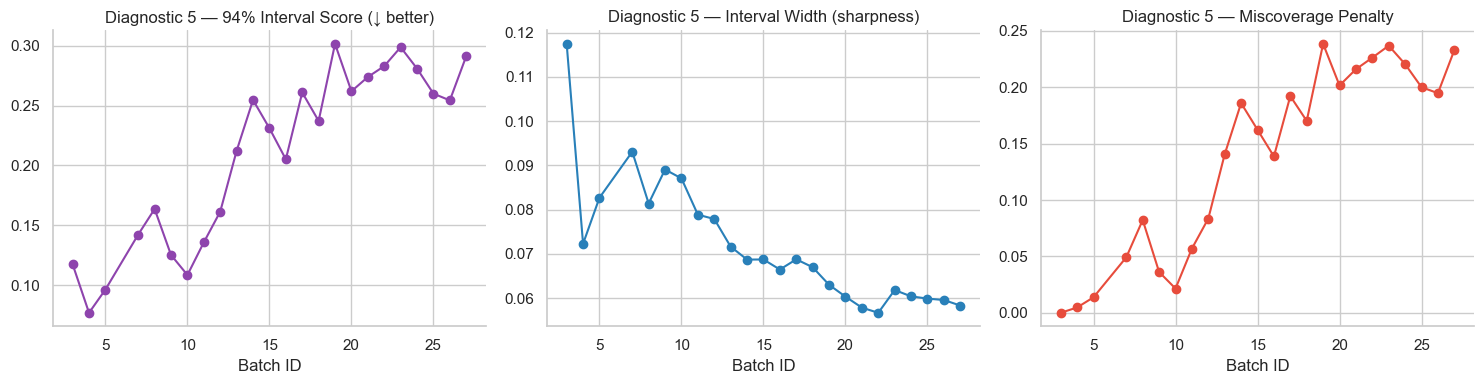

 Batch_ID  Mean_Score  Mean_Width  Mean_Penalty
        3      0.1175      0.1175        0.0000
        4      0.0770      0.0723        0.0047
        5      0.0964      0.0827        0.0137
        7      0.1423      0.0931        0.0493
        8      0.1637      0.0814        0.0823
        9      0.1253      0.0891        0.0362
       10      0.1086      0.0871        0.0215
       11      0.1358      0.0789        0.0570
       12      0.1615      0.0779        0.0836
       13      0.2122      0.0716        0.1406
       14      0.2547      0.0687        0.1860
       15      0.2311      0.0687        0.1624
       16      0.2051      0.0665        0.1387
       17      0.2609      0.0688        0.1922
       18      0.2372      0.0670        0.1702
       19      0.3015      0.0630        0.2385
       20      0.2619      0.0603        0.2016
       21      0.2739      0.0578        0.2160
       22      0.2829      0.0567        0.2263
       23      0.2987      0.0618       

In [46]:
LEVEL = 0.94
alpha = 1 - LEVEL
interval_records = []

for batch_id, trace in model_traces.items():
    samples = get_posterior_samples(trace, baseline_array, n_races)
    lower   = np.quantile(samples, alpha / 2,       axis=0)  # (n_races,)
    upper   = np.quantile(samples, 1 - alpha / 2,   axis=0)  # (n_races,)

    for i, race in enumerate(all_races):
        y    = official_dem_prop.loc[race]
        L, U = lower[i], upper[i]
        width   = U - L
        penalty = (2 / alpha) * max(0.0, L - y) + (2 / alpha) * max(0.0, y - U)
        interval_records.append({
            'Batch_ID': batch_id,
            'Race':     race,
            'Score':    width + penalty,
            'Width':    width,
            'Penalty':  penalty,
        })

interval_df = pd.DataFrame(interval_records)

agg_int = interval_df.groupby('Batch_ID').agg(
    Mean_Score   = ('Score',   'mean'),
    Mean_Width   = ('Width',   'mean'),
    Mean_Penalty = ('Penalty', 'mean'),
).reset_index()

# --- plot ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
panels = [
    ('Mean_Score',   f'{int(LEVEL*100)}% Interval Score (↓ better)', '#8e44ad'),
    ('Mean_Width',   'Interval Width (sharpness)',                    '#2980b9'),
    ('Mean_Penalty', 'Miscoverage Penalty',                           '#e74c3c'),
]
for ax, (col, title, color) in zip(axes, panels):
    ax.plot(agg_int['Batch_ID'], agg_int[col], marker='o', color=color)
    ax.set_xlabel('Batch ID')
    ax.set_title(f'Diagnostic 5 — {title}')
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

print(agg_int.round(4).to_string(index=False))